# Property Price Tier Classification (Dubai)
## Decision Tree vs Logistic Regression

Goal: classify **sales** transactions into **Low, Medium, High** price tiers using transaction, property, and location attributes.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("clean_transactions_pandas.csv")

print("Original shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\ntrans_group_en unique values:", df["trans_group_en"].dropna().unique())

Original shape: (469409, 32)

Columns: ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_en', 'property_sub_type_id', 'property_sub_type_en', 'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en', 'building_name_en', 'project_number', 'project_name_en', 'master_project_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']

trans_group_en unique values: ['Gifts' 'Mortgages' 'Sales']


## 1. Filter to Sales Transactions

Only sale transactions are relevant for price tier classification.

In [4]:
# Keep only Sales
df = df[df["trans_group_en"] == "Sales"].copy()

print("After filtering Sales:", df.shape)

# Remove rows missing essential numeric features
df = df.dropna(subset=["actual_worth", "procedure_area"])

print("After dropping missing actual_worth and procedure_area:", df.shape)

After filtering Sales: (359066, 32)
After dropping missing actual_worth and procedure_area: (359066, 32)


## 2. Feature Engineering

- Extract transaction year and month.
- Convert room descriptions into numeric format.

In [5]:
# Convert instance_date to datetime
df["instance_date"] = pd.to_datetime(df["instance_date"], errors="coerce")

# Remove rows where date failed conversion
df = df.dropna(subset=["instance_date"])

# Extract year and month
df["year"] = df["instance_date"].dt.year
df["month"] = df["instance_date"].dt.month

# Clean rooms
df["rooms_en"] = df["rooms_en"].astype(str)

# Extract numeric part from strings like "2 B/R"
df["rooms_clean"] = df["rooms_en"].str.extract(r"(\d+)")

# Assign 0 to Studio
df.loc[df["rooms_en"].str.contains("Studio", case=False, na=False), "rooms_clean"] = 0

# Convert to numeric
df["rooms_clean"] = pd.to_numeric(df["rooms_clean"], errors="coerce")

print("Unique cleaned room values:")
print(sorted(df["rooms_clean"].dropna().unique()))

print("Current shape:", df.shape)

Unique cleaned room values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(9.0)]
Current shape: (359066, 35)


## 3. Define Target Variable (Price Tier)

Price tiers are defined using business thresholds on `actual_worth`:

- Low: < 1,000,000 AED  
- Medium: 1,000,000 to < 3,000,000 AED  
- High: ≥ 3,000,000 AED  

This provides economically meaningful segmentation.

In [6]:
def price_category(price):
    if price < 1_000_000:
        return "Low"
    elif price < 3_000_000:
        return "Medium"
    else:
        return "High"

df["price_class"] = df["actual_worth"].apply(price_category)

print("Price class distribution:")
print(df["price_class"].value_counts())

print("\nClass proportions:")
print(df["price_class"].value_counts(normalize=True))

Price class distribution:
price_class
Medium    161464
Low       129141
High       68461
Name: count, dtype: int64

Class proportions:
price_class
Medium    0.449678
Low       0.359658
High      0.190664
Name: proportion, dtype: float64


## 4. Select Modeling Features

Structural, locational, and transaction attributes are selected.
Rows missing required feature values are removed.

In [7]:
features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en",
    "year",
    "month"
]

df_model = df[features + ["price_class"]].copy()

print("Before dropna:", df_model.shape)
print("\nMissing values:\n", df_model.isnull().sum())

df_model = df_model.dropna()

print("\nAfter dropna:", df_model.shape)

Before dropna: (359066, 10)

Missing values:
 procedure_area           0
rooms_clean          75534
has_parking              0
property_type_en         0
property_usage_en        0
area_name_en             0
reg_type_en              0
year                     0
month                    0
price_class              0
dtype: int64

After dropna: (283532, 10)


### Data Cleaning Justification

Approximately 75,000 rows were removed due to missing `rooms_clean` values.  
Since number of rooms is a structural attribute directly linked to pricing, incomplete records were excluded to ensure consistent feature representation.

The remaining dataset contains over 280,000 transactions, which remains sufficiently large for robust modeling.

## 5. Train/Test Split (Stratified)

A stratified split preserves class proportions across training and testing sets.

In [8]:
X = df_model[features]
y = df_model["price_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (226825, 9)
Testing shape: (56707, 9)

Training class distribution:
price_class
Medium    0.466285
Low       0.405802
High      0.127914
Name: proportion, dtype: float64

Testing class distribution:
price_class
Medium    0.466292
Low       0.405788
High      0.127921
Name: proportion, dtype: float64


### Stratified Sampling Verification

Stratified splitting preserved the original class proportions in both training and testing sets.

This ensures that model evaluation reflects realistic market distribution and avoids bias toward majority classes.

## 6. Preprocessing

Categorical features are encoded using One-Hot Encoding.
Numeric features are passed through.

In [9]:
categorical_features = [
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en"
]

numeric_features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "year",
    "month"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## 7. Model 1: Decision Tree Classifier

A tree-based model is trained to classify properties into Low, Medium, and High price tiers.

In [10]:
dt_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8842999982365493

Decision Tree Classification Report:

              precision    recall  f1-score   support

        High       0.84      0.85      0.84      7254
         Low       0.90      0.91      0.91     23011
      Medium       0.88      0.87      0.88     26442

    accuracy                           0.88     56707
   macro avg       0.87      0.88      0.88     56707
weighted avg       0.88      0.88      0.88     56707



### Decision Tree Performance Interpretation

The Decision Tree achieves strong performance across all price tiers, particularly for Low and Medium properties.

Its superior performance suggests that property pricing relationships are nonlinear and involve interaction effects between features.

### 7.1 Decision Tree Confusion Matrix

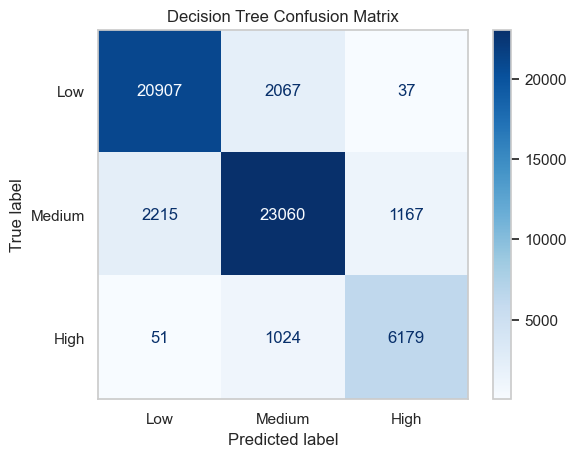

In [12]:
cm_dt = confusion_matrix(y_test, dt_pred, labels=["Low", "Medium", "High"])
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                 display_labels=["Low", "Medium", "High"])

disp_dt.plot(cmap="Blues", values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.grid(False)
plt.show()

## 8. Model 2: Logistic Regression (Multinomial)

A linear model is trained to classify price tiers.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Identify categorical vs numeric columns
categorical_features = [
    "property_type_en",
    "property_usage_en",
    "area_name_en",
    "reg_type_en"
]

numeric_features = [
    "procedure_area",
    "rooms_clean",
    "has_parking",
    "year",
    "month"
]

# 2) Preprocess: One-Hot for categoricals, scale numerics
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

# 3) Build Logistic Regression pipeline
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

# 4) Train
logreg_model.fit(X_train, y_train)

# 5) Predict and evaluate
y_pred_log = logreg_model.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_acc)

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.811293138413247

Logistic Regression Classification Report:

              precision    recall  f1-score   support

        High       0.79      0.65      0.71      7254
         Low       0.85      0.85      0.85     23011
      Medium       0.78      0.82      0.80     26442

    accuracy                           0.81     56707
   macro avg       0.81      0.77      0.79     56707
weighted avg       0.81      0.81      0.81     56707



### Logistic Regression Performance Interpretation

Logistic Regression performs well for Low and Medium tiers but shows weaker recall for the High tier.

This indicates that premium property pricing may involve nonlinear patterns that are not fully captured by a linear decision boundary.

### 8.1 Logistic Regression Confusion Matrix

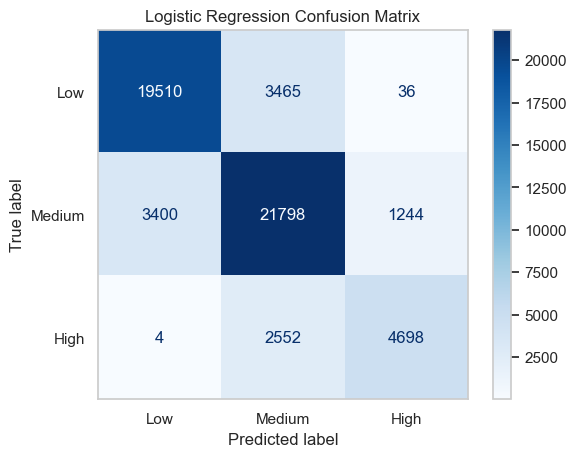

In [14]:
cm_log = confusion_matrix(y_test, y_pred_log, labels=["Low", "Medium", "High"])

disp_log = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Low", "Medium", "High"]
)

disp_log.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.show()

## 9. Model Comparison Summary

In [15]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression"],
    "Accuracy": [dt_acc, log_acc]
})

results

,Model,Accuracy
0,Decision Tree,0.884300
1,Logistic Regression,0.811293


## 10. Cross-Validation (Model Stability)

5-fold stratified cross-validation is used to evaluate stability and generalization.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_cv = cross_val_score(dt_pipeline, X, y, cv=cv, scoring="accuracy")
log_cv = cross_val_score(logreg_model, X, y, cv=cv, scoring="accuracy")

print("Decision Tree CV Accuracy: mean =", dt_cv.mean(), ", std =", dt_cv.std())
print("Logistic Regression CV Accuracy: mean =", log_cv.mean(), ", std =", log_cv.std())

Decision Tree CV Accuracy: mean = 0.8841682845827901 , std = 0.0011346640746004786
Logistic Regression CV Accuracy: mean = 0.8109631201763253 , std = 0.0019646594501133738


### Cross-Validation Stability

Both models show very low standard deviation across folds, indicating stable generalization performance.

The Decision Tree consistently outperforms Logistic Regression across all folds.

## 11. Most Influential Attributes

Feature importance is extracted from the Decision Tree model.
This provides insight into which variables most strongly influence price tier classification.

In [17]:
# Extract one-hot encoded feature names
ohe = dt_pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([ohe_feature_names, numeric_features])

dt_model = dt_pipeline.named_steps["model"]

importance = pd.Series(
    dt_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

importance.head(15)

procedure_area                                    0.465697
year                                              0.131112
month                                             0.066027
reg_type_en_Existing Properties                   0.038310
area_name_en_Burj Khalifa                         0.022733
area_name_en_Business Bay                         0.022686
rooms_clean                                       0.021997
area_name_en_Marsa Dubai                          0.020440
area_name_en_Al Barsha South Fourth               0.015597
property_usage_en_Residential                     0.012029
reg_type_en_Off-Plan Properties                   0.011849
area_name_en_Palm Jumeirah                        0.011172
property_usage_en_Hospitality                     0.007957
area_name_en_Al Khairan First                     0.007532
area_name_en_Hadaeq Sheikh Mohammed Bin Rashid    0.007420
dtype: float64

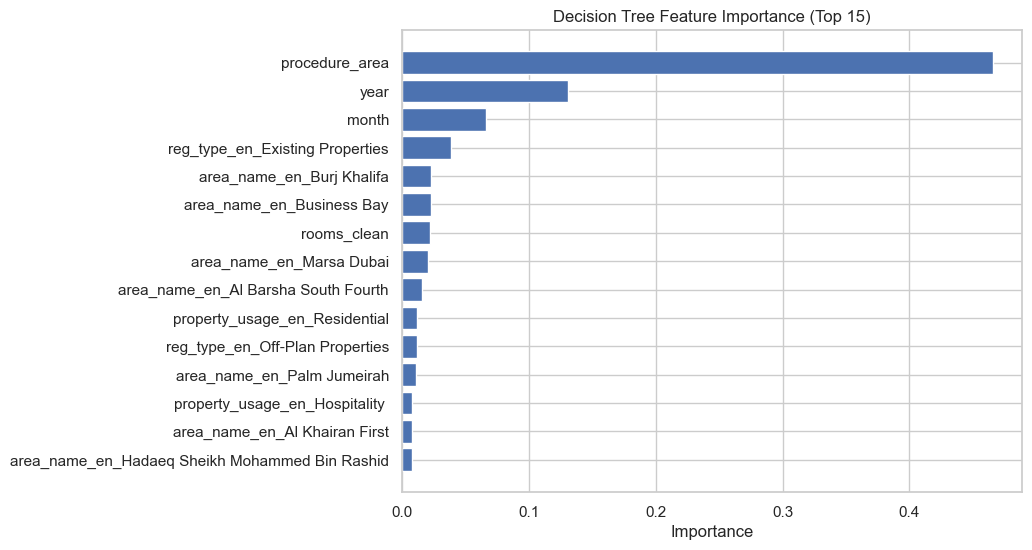

In [18]:
top15 = importance.head(15).sort_values()

plt.figure(figsize=(8,6))
plt.barh(top15.index, top15.values)
plt.title("Decision Tree Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.show()

### Key Drivers of Price Tier Classification

`procedure_area` is the dominant predictor of price tier, substantially outweighing other features.

Temporal variables (year, month) and certain premium locations also contribute meaningfully.

This confirms that property size and market timing are primary drivers of pricing segmentation in Dubai.

## 12. Classification Conclusions

The Decision Tree model outperformed Logistic Regression across all evaluation metrics.

Key findings:

- Tree-based modeling achieved significantly higher accuracy.
- Logistic Regression struggled particularly with the minority High class.
- Feature importance analysis revealed that property size (procedure_area) is the dominant driver of price tier classification.
- Transaction timing (year, month) and premium locations further refine classification boundaries.

These results suggest that property price tiers exhibit nonlinear and interaction-based patterns that are better captured by tree-based models.